### Assumptions:
- Assumes 20% tax on pension (lowest tax rate in UK, ~lowest tax rates + skladka zdrowotna in Poland)
- Assumes no changes to the taxes
- Assumes the annual return rates for the last 10 years for both SP500 and the pension fund I am in
- Assumes capital gains tax allowance is used to the fullest each year (3,000 a year) and doesn't change over time

### Simplifications
- Ignores the 30 day cooling period when selling SP500 to use the capital gains tax allowance
- Ignores the fact that pension can only be acessed at 57 while ETF money can be accessed at any time
- Ignores taxes on dividends from ETFs (but there is an allowance of 500 a year)
- Ignores a 25% free of tax lump sum payment for the pension (probably not valid when receiving pension abroad)


In [1]:
# Parameters
years = 30
pension_return = 0.0959
etf_return = 0.1539
pension_tax = 0.20
cg_tax = 0.24
pre_tax_etf = 0.45  # 45% upfront tax on ETF contribution

# Annual contributions
split_pension_contrib = 20400
split_etf_contrib = 39600
all_pension_contrib = 60000

# --- Split strategy: start-of-year ---
def simulate_js_match_start():
    pension_balance = 0
    etf_balance = 0
    etf_cost_basis = 0
    for year in range(years):
        # Contributions at start
        pension_balance += split_pension_contrib
        etf_net_contrib = split_etf_contrib * (1 - pre_tax_etf)
        etf_balance += etf_net_contrib
        etf_cost_basis += etf_net_contrib

        # Apply annual returns
        pension_balance *= (1 + pension_return)
        etf_balance *= (1 + etf_return)

    # Taxes
    pension_balance *= (1 - pension_tax)

    # ETF gains taxed at end
    etf_gain = etf_balance - etf_cost_basis
    tax = etf_gain * cg_tax if etf_gain > 0 else 0

    # Apply allowance: 10 years × 3000 = 30,000
    tax -= 3000 * 10
    tax = max(tax, 0)  # tax cannot be negative
    etf_balance -= tax

    return pension_balance + etf_balance

# --- Split strategy: end-of-year ---
def simulate_js_match_end():
    pension_balance = 0
    etf_balance = 0
    etf_cost_basis = 0
    for year in range(years):
        # Apply returns first
        pension_balance *= (1 + pension_return)
        etf_balance *= (1 + etf_return)

        # Add contributions at end
        pension_balance += split_pension_contrib
        etf_net_contrib = split_etf_contrib * (1 - pre_tax_etf)
        etf_balance += etf_net_contrib
        etf_cost_basis += etf_net_contrib

    # Taxes
    pension_balance *= (1 - pension_tax)

    # ETF gains taxed at end
    etf_gain = etf_balance - etf_cost_basis
    tax = etf_gain * cg_tax if etf_gain > 0 else 0

    # Apply allowance: 9 years × 3000 = 27,000
    tax -= 3000 * 9
    tax = max(tax, 0)
    etf_balance -= tax

    return pension_balance + etf_balance

# --- All-pension strategy: start-of-year ---
def simulate_all_start():
    pension_balance = 0
    for year in range(years):
        pension_balance += all_pension_contrib
        pension_balance *= (1 + pension_return)
    pension_balance *= (1 - pension_tax)
    return pension_balance

# --- All-pension strategy: end-of-year ---
def simulate_all_end():
    pension_balance = 0
    for year in range(years):
        pension_balance *= (1 + pension_return)
        pension_balance += all_pension_contrib
    pension_balance *= (1 - pension_tax)
    return pension_balance

# Run simulations
results = {
    "All-Pension (year-start)": simulate_all_start(),
    "JS Match (year-start)": simulate_js_match_start(),
    "All-Pension (year-end)": simulate_all_end(),
    "JS Match (year-end)": simulate_js_match_end()
}

# Group by approach
approaches = ["year-start", "year-end"]

for approach in approaches:
    pension_key = f"All-Pension ({approach})"
    etf_key = f"JS Match ({approach})"
    
    print(f"\n=== {approach.replace('-', ' ').title()} Contributions ===")
    print(f"{pension_key}: £{results[pension_key]:,.0f}")
    print(f"{etf_key}: £{results[etf_key]:,.0f}")
    
    ratio = results[pension_key] / results[etf_key]
    print(f"Pension / ETF ratio: {ratio*100:.2f}%")


=== Year Start Contributions ===
All-Pension (year-start): £8,008,475
JS Match (year-start): £11,881,501
Pension / ETF ratio: 67.40%

=== Year End Contributions ===
All-Pension (year-end): £7,307,670
JS Match (year-end): £10,443,624
Pension / ETF ratio: 69.97%


## Graph ratio depending on the number of years

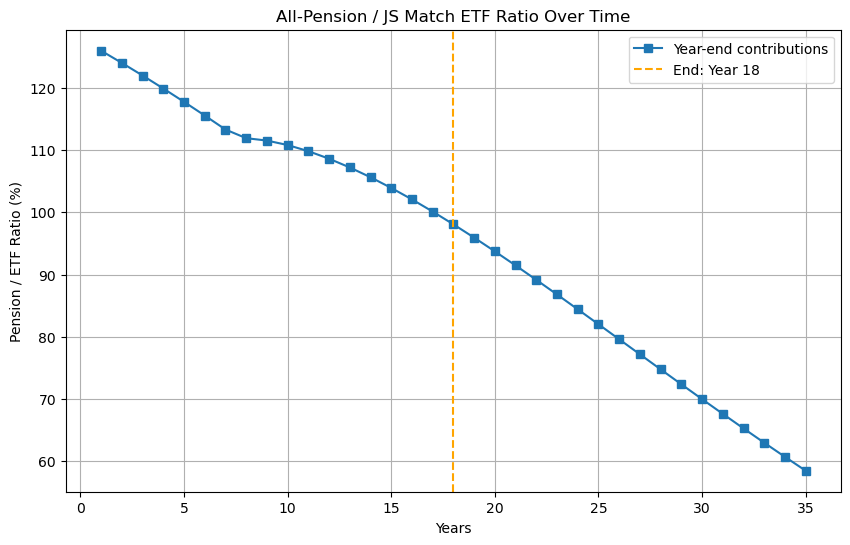

In [17]:
import matplotlib.pyplot as plt

# Store results
years_range = range(1, 36)
ratios_start = []
ratios_end = []

for y in years_range:
    # Update the global years variable for the simulation
    years = y
    
    # Compute results using existing functions
    all_start = simulate_all_start()
    split_start = simulate_js_match_start()
    all_end = simulate_all_end()
    split_end = simulate_js_match_end()
    
    # Compute ratios (All-Pension / JS Match ETF)
    ratios_start.append((all_start / split_start) * 100)
    ratios_end.append((all_end / split_end) * 100)

# Find first year where ratio is less than 1
first_below_1_start = next((year for year, r in zip(years_range, ratios_start) if r <= 100), None)
first_below_1_end = next((year for year, r in zip(years_range, ratios_end) if r <= 100), None)

# Plot
plt.figure(figsize=(10, 6))
#plt.plot(years_range, ratios_start, marker='o', label="Year-start contributions")
plt.plot(years_range, ratios_end, marker='s', label="Year-end contributions")

# Add vertical lines
#if first_below_1_start:
    #plt.axvline(x=first_below_1_start, color='blue', linestyle='--', label=f"Start: Year {first_below_1_start}")
if first_below_1_end:
    plt.axvline(x=first_below_1_end, color='orange', linestyle='--', label=f"End: Year {first_below_1_end}")

plt.title("All-Pension / JS Match ETF Ratio Over Time")
plt.xlabel("Years")
plt.ylabel("Pension / ETF Ratio (%)")
plt.grid(True)
plt.legend()
plt.show()